<a href="https://colab.research.google.com/github/a00839600-cloud/Avance-1/blob/main/Avance_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
%pip install alpaca-trade-api
%pip install mplfinance
%pip install scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.9/84.9 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.8/123.8 kB 7.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 725.0/725.0 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 11.2 MB/s eta 0:00:00
  Created wheel for msgpack: filename=msgpack-1.0.3-cp312-cp312-linux_x86_64.whl size=15688 sha256=d2e6d61d2a113dc3e0d47495ff590665a10132ddaad4ad7cf7a68205e10f1227
  Stored in directory: /root/.cache/pip/wheels/ba/bd/3f/f043e8f634db9c90ae128d631f43ae9990eef01274a63291f9
  Created wheel for websockets: filename=websockets-10.4-cp312-cp312-linux_x86_64.whl size=107328 sha256=b162a0582b7f8b6322ad81dca7b214ef259e44f8e6f4d78b73a28e7116f37136
  Stored in directory: /root/.cache/pip/wheels/80/cf/6d/5d7e4c920cb41925a1

Iniciando análisis de tickers...

Generando gráfico para AAPL...


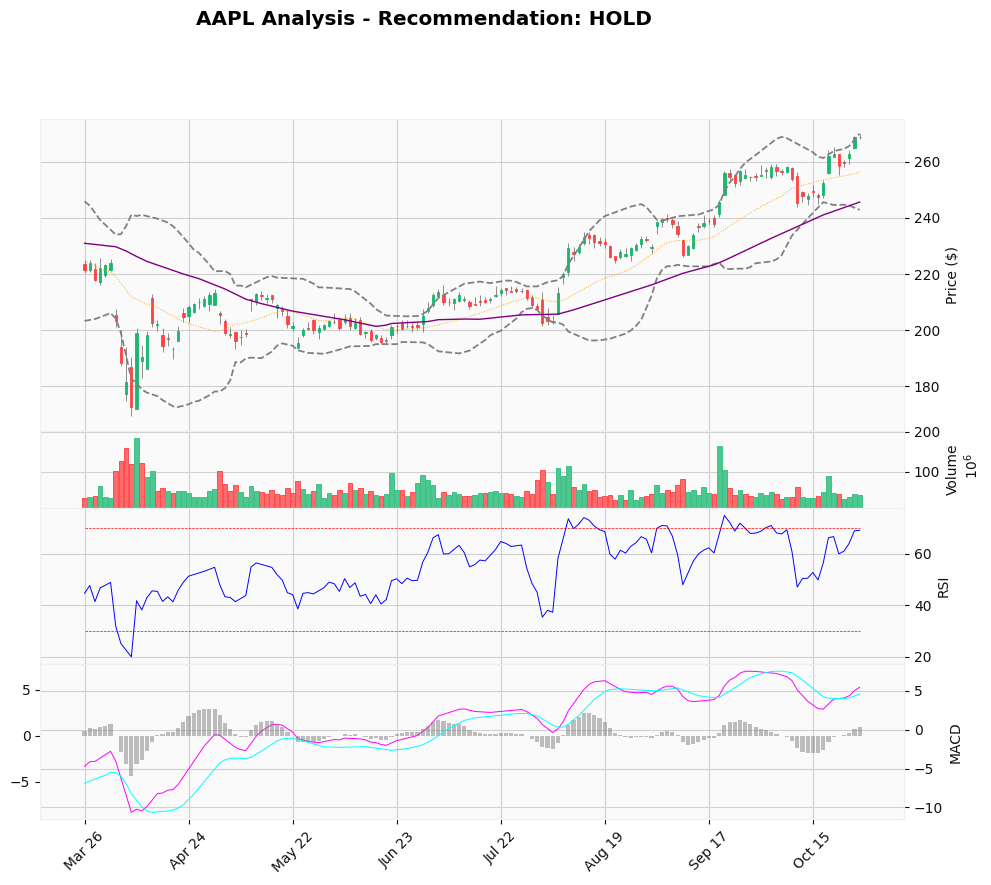


Generando gráfico para META...


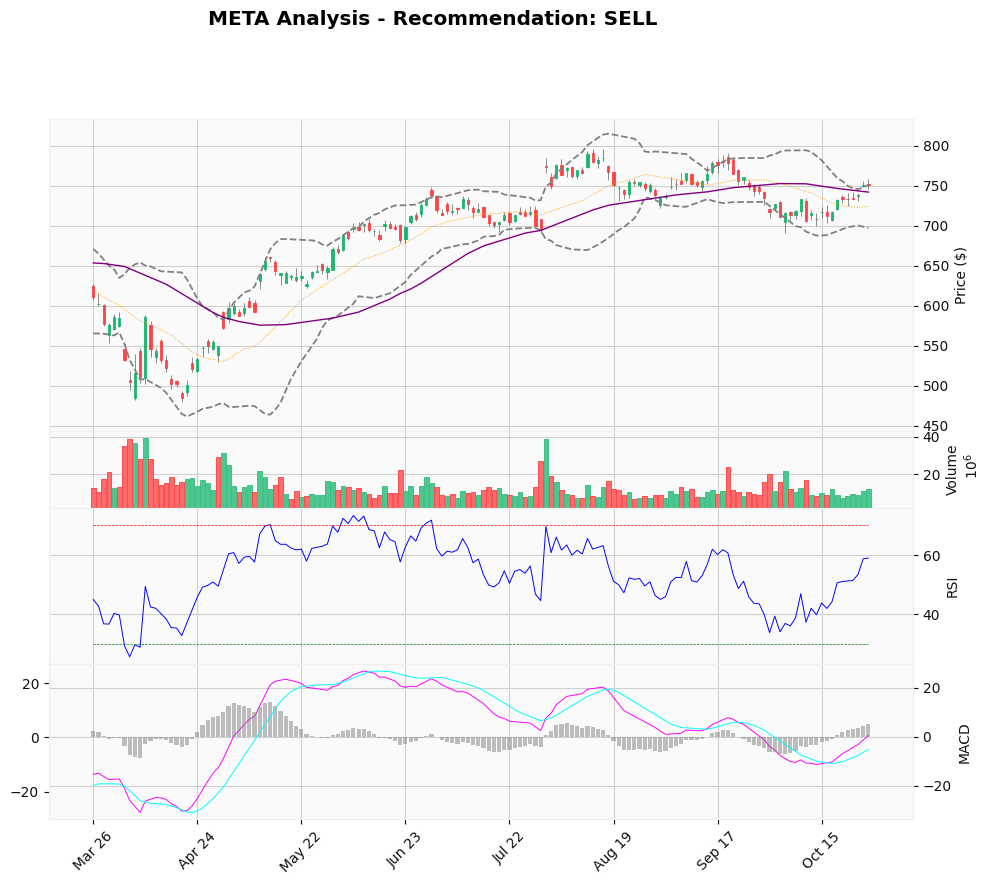


Generando gráfico para NVDA...


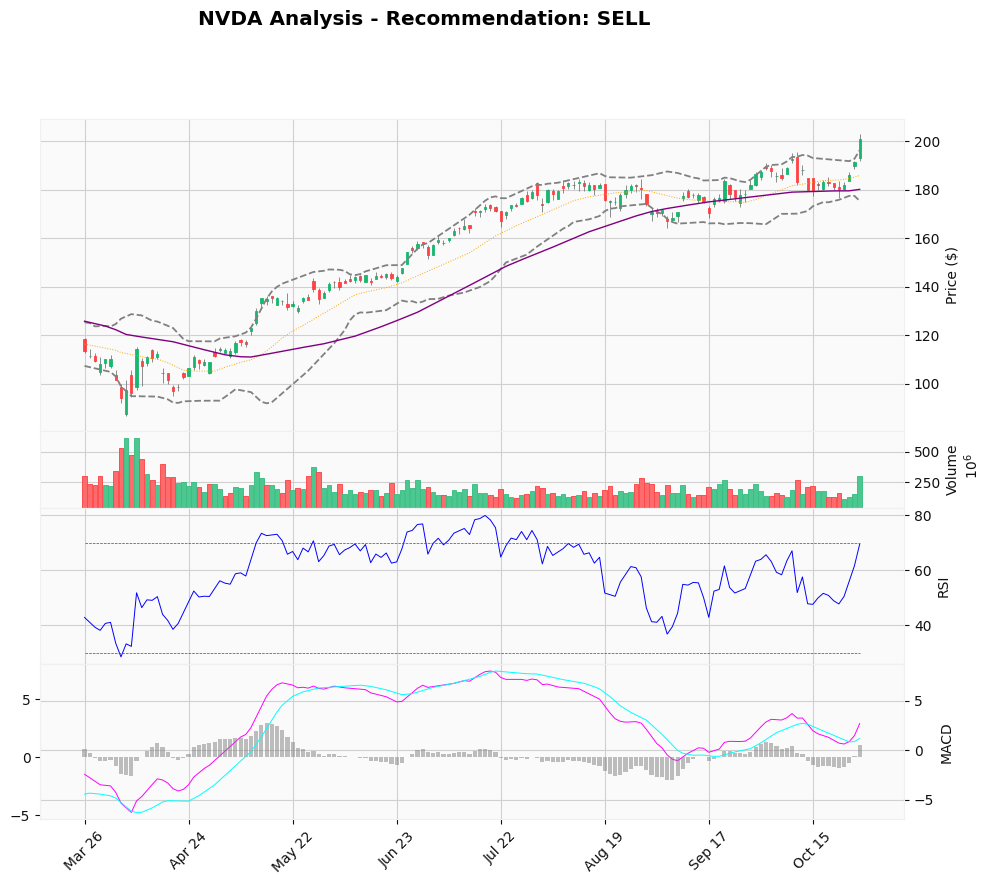


Generando gráfico para MSFT...


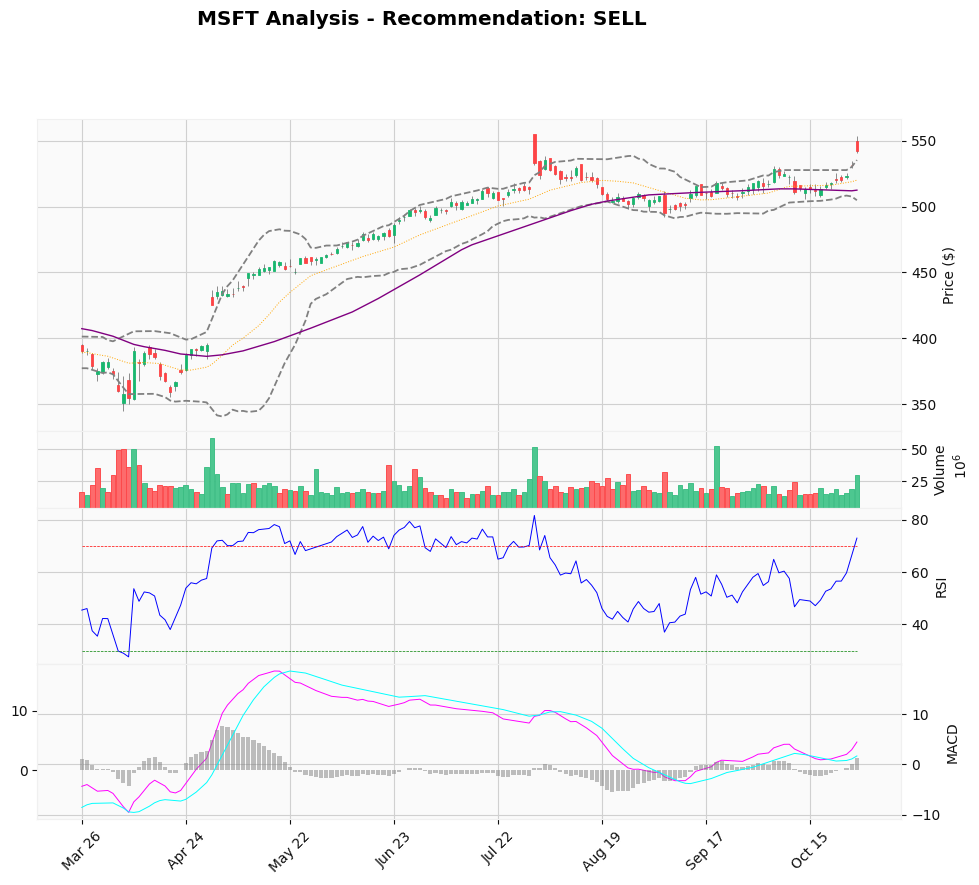


Generando gráfico para GOOGL...


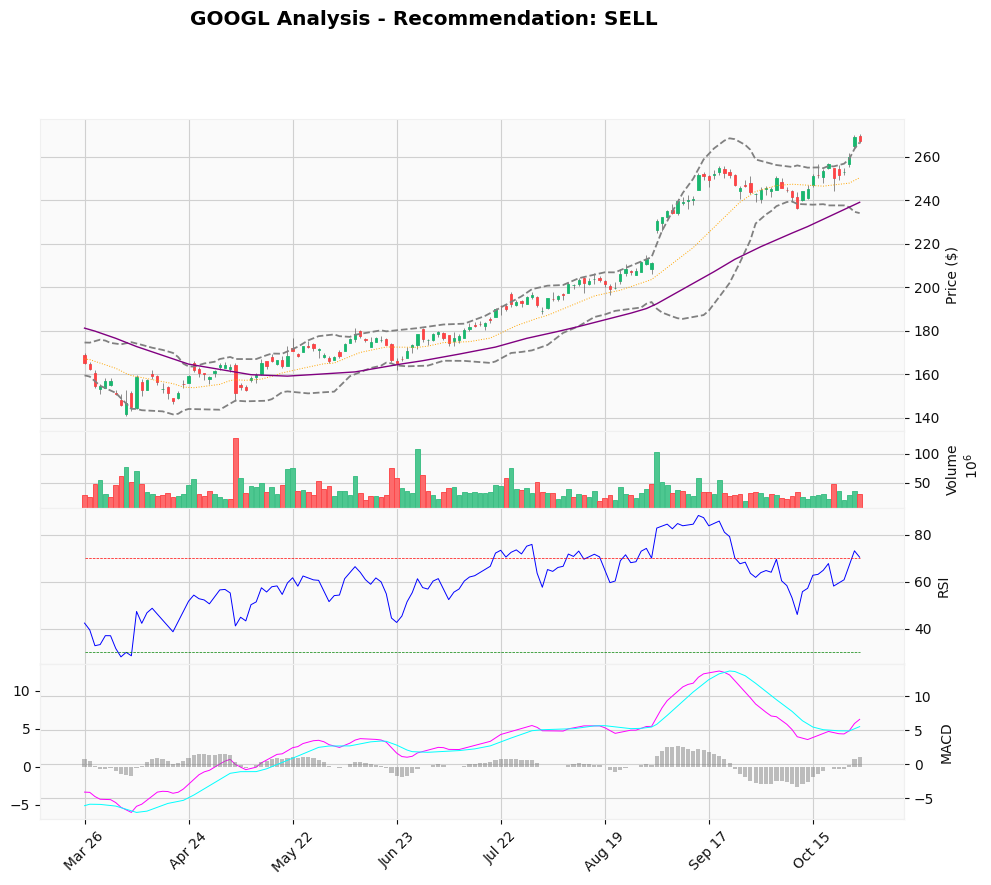


Generando gráfico para TSLA...


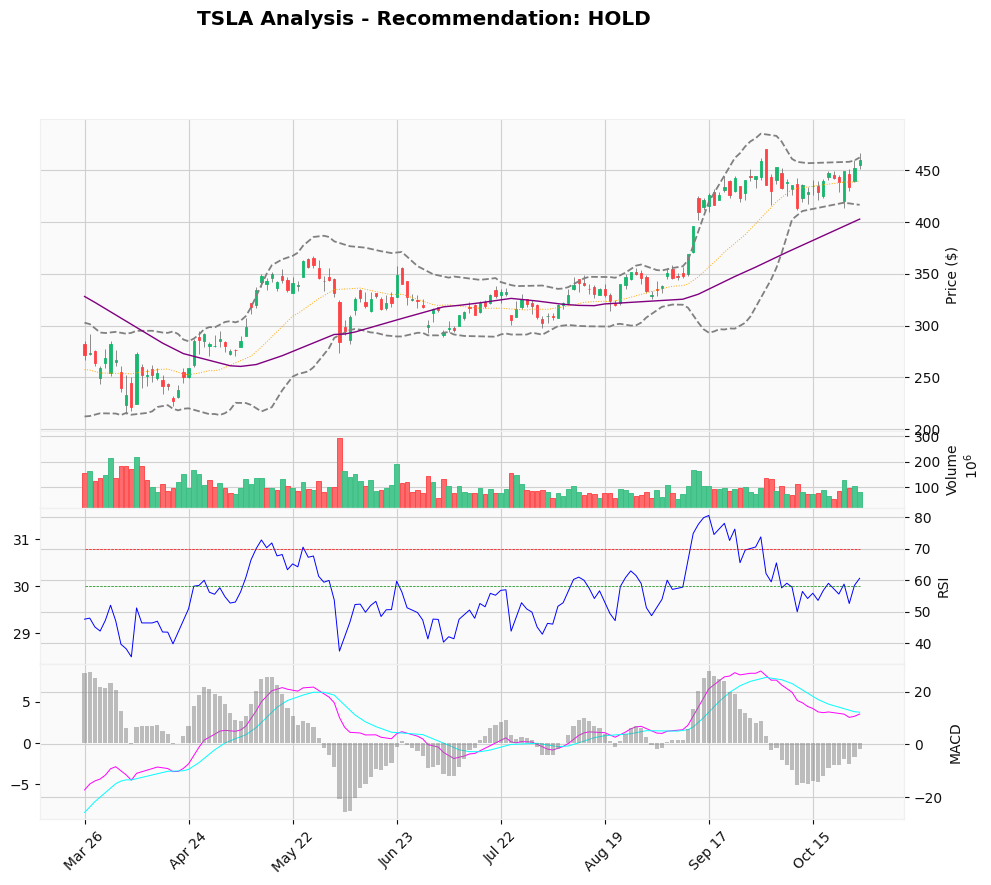


Generando gráfico para AMZN...


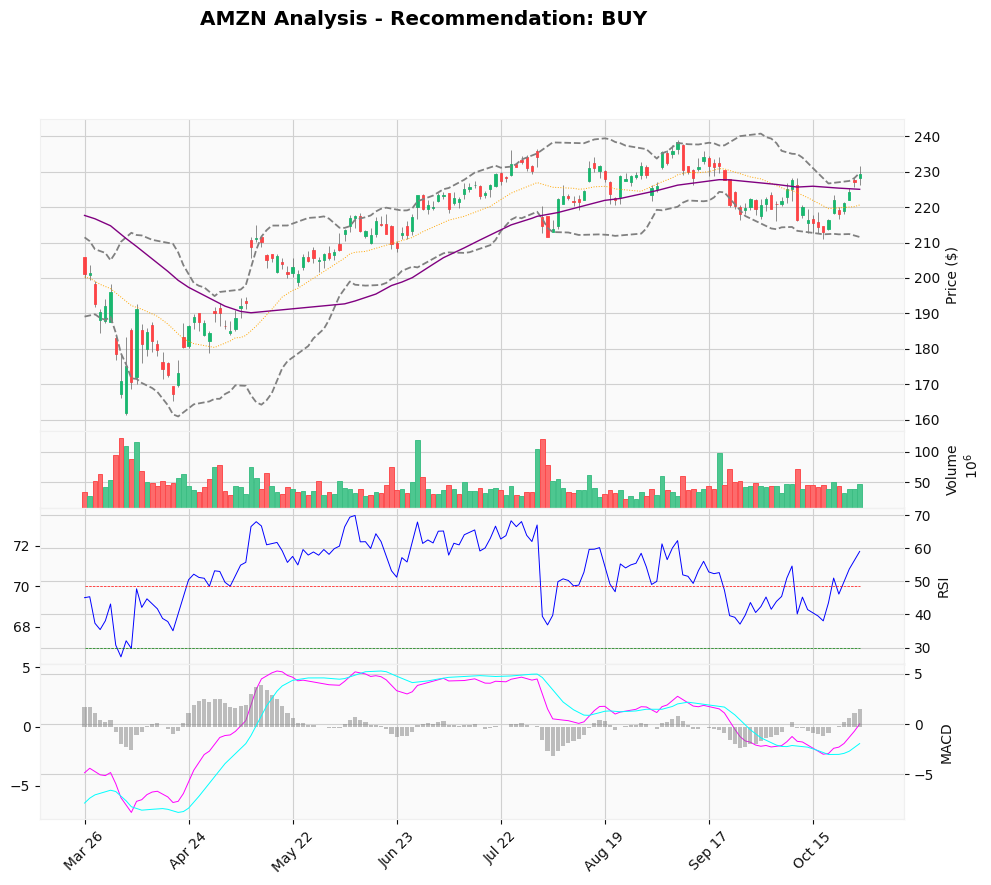



========================= RESUMEN DE SEÑALES (HOY) =========================
Ticker: AAPL
  Close: 269.00 | SMA50: 245.65 | RSI: 69.17
  MACD ahora: 5.4648 Señal: 4.5123
  🚨 PATRÓN DETECTADO: NEUTRAL
----------------------------------------------------------------------
  Horizonte 1d:
  ├─ Estados: MACD: neutral | SMA50: bullish | RSI: neutral | BB: neutral
  ├─ Patrón: NEUTRAL
  └─ Tendencia: neutral → HOLD
  Horizonte 5d:
  ├─ Estados: MACD: neutral | SMA50: bullish | RSI: neutral | BB: neutral
  ├─ Patrón: NEUTRAL
  └─ Tendencia: neutral → HOLD
Ticker: META
  Close: 751.44 | SMA50: 742.04 | RSI: 59.00
  MACD ahora: 0.5008 Señal: -4.3349
  🚨 PATRÓN DETECTADO: NEUTRAL
----------------------------------------------------------------------
  Horizonte 1d:
  ├─ Estados: MACD: neutral | SMA50: bullish | RSI: neutral | BB: overbought
  ├─ Patrón: NEUTRAL
  └─ Tendencia: neutral (reversion_sell_signal) → SELL
  Horizonte 5d:
  ├─ Estados: MACD: neutral | SMA50: bullish | RSI: neutral | B

Señales generadas para AAPL.
Resultados Backtest AAPL: {'total_return_pct': -11.76035052939195, 'sharpe_ratio': -0.31852195092017926, 'num_trades': 42}

Generando señales iterativas para META (de 2023-06-27 a 2025-10-28)...


Señales generadas para META.
Resultados Backtest META: {'total_return_pct': 13.052422315822776, 'sharpe_ratio': 0.7974167002538047, 'num_trades': 28}

Generando señales iterativas para NVDA (de 2023-06-27 a 2025-10-28)...


Señales generadas para NVDA.
Resultados Backtest NVDA: {'total_return_pct': 40.706435517827174, 'sharpe_ratio': 1.0339195564727017, 'num_trades': 28}

Generando señales iterativas para MSFT (de 2023-06-27 a 2025-10-28)...


Señales generadas para MSFT.
Resultados Backtest MSFT: {'total_return_pct': 11.58978238004542, 'sharpe_ratio': 0.572223208249703, 'num_trades': 46}

Generando señales iterativas para GOOGL (de 2023-06-27 a 2025-10-28)...
Señales generadas para GOOGL.
Resultados Backtest GOOGL: {'total_return_pct': 5.007516504949505, 'sharpe_ratio': 0.3767337786085922, 'num_trades': 30}

Generando señales iterativas para TSLA (de 2023-06-27 a 2025-10-28)...


Señales generadas para TSLA.
Resultados Backtest TSLA: {'total_return_pct': -11.344502694661962, 'sharpe_ratio': -0.37445954757316857, 'num_trades': 28}

Generando señales iterativas para AMZN (de 2023-06-27 a 2025-10-28)...
Señales generadas para AMZN.
Resultados Backtest AMZN: {'total_return_pct': -1.3861641603371222, 'sharpe_ratio': -0.00018788359953323224, 'num_trades': 32}

[INFO] TRADE_ENABLED=False → no se enviaron órdenes.

[INFO] Mostrando gráficos... Cierra las ventanas de los gráficos para finalizar el script.


In [12]:
import os
import warnings
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd
import mplfinance as mpf
import matplotlib.pyplot as plt

# --- Imports de Análisis ---
from statsmodels.tsa.arima.model import ARIMA
from scipy.signal import find_peaks
from scipy.stats import linregress

# --- Imports de API (Alpaca) ---
try:
    from alpaca_trade_api.rest import REST, TimeFrame
except ImportError:
    print("Instalando 'alpaca-trade-api'...")
    import subprocess
    subprocess.check_call(["pip", "install", "alpaca-trade-api"])
    from alpaca_trade_api.rest import REST, TimeFrame

warnings.filterwarnings("ignore")

# ==================== CONFIGURACIÓN ALPACA ====================
# ¡¡No escribas tus claves API directamente en el código!!
# Es mejor usar variables de entorno.
API_KEY = os.environ.get("APCA_API_KEY_ID", "PK6PR8K71SUI4RGI2JMB")
API_SECRET = os.environ.get("APCA_API_SECRET_KEY", "2t6mK57kzfZNFJKVKIAAEI7Grvj0rOrSajwnVXvq")
BASE_URL = "https://paper-api.alpaca.markets"

ALPACA_CLIENT = None

def _alpaca_client() -> REST:
    """Instancia global única del cliente Alpaca."""
    global ALPACA_CLIENT
    if ALPACA_CLIENT is None:
        try:
            ALPACA_CLIENT = REST(API_KEY, API_SECRET, base_url=BASE_URL)
            ALPACA_CLIENT.get_account()
        except Exception as e:
            raise ConnectionError(f"Error al conectar con Alpaca: {e}")
    return ALPACA_CLIENT

def get_alpaca_data(ticker: str, start_date: str, end_date: str, timeframe: str = "1Day") -> pd.DataFrame:
    """
    Descarga datos históricos de Alpaca.
    """
    alpaca = _alpaca_client()
    tf_map = {"1Day": TimeFrame.Day, "1Hour": TimeFrame.Hour}
    if timeframe not in tf_map:
        raise ValueError("Solo se soporta '1Day' o '1Hour'")

    try:
        bars = alpaca.get_bars(ticker, tf_map[timeframe], start=start_date, end=end_date).df
    except Exception as e:
        raise RuntimeError(f"Error descargando datos de Alpaca: {e}")

    if bars.empty:
        raise ValueError(f"Sin datos de Alpaca para {ticker} entre {start_date} y {end_date}")

    # Limpieza y renombrado de columnas
    if 'symbol' in bars.columns:
        bars = bars[bars["symbol"] == ticker].copy()
    if 'timestamp' in bars.columns:
        bars = bars.set_index("timestamp")

    bars.index = pd.to_datetime(bars.index, utc=True).tz_convert('America/New_York')
    bars.index = bars.index.date
    bars.index = pd.to_datetime(bars.index)

    bars = bars.rename(columns={
        "open": "Open", "high": "High", "low": "Low", "close": "Close", "volume": "Volume"
    }, errors='ignore')

    bars["Adj Close"] = bars["Close"]
    return bars

# ==================== PARÁMETROS GLOBALES ====================
TICKERS = ["AAPL", "META", "NVDA", "MSFT", "GOOGL", "TSLA", "AMZN"] # Canasta
START_DATE = "2023-01-01"
END_DATE   = "2025-10-28" # Nota: Usar fechas futuras puede traer datos parciales
FORECAST_HORIZONS = [1, 5]

# Parámetros de patrones
PATTERN_LOOKBACK = 120
PEAK_VALLEY_ORDER = 10

# Flags de ejecución
PLOT_CHARTS = True
TRADE_ENABLED = False
RUN_BACKTEST = True
LONG_ONLY = True
TARGET_QTY = 1

# ==================== INDICADORES ====================

def EMA(series: pd.Series, period: int) -> pd.Series:
    return series.ewm(span=period, adjust=False).mean()

def calcular_SMA(series: pd.Series, period: int) -> pd.Series:
    return series.rolling(window=period, min_periods=1).mean()

def calcular_MACD(close_series: pd.Series, fast: int = 12, slow: int = 26, signal: int = 9):
    ema_fast = EMA(close_series, fast)
    ema_slow = EMA(close_series, slow)
    macd_line = ema_fast - ema_slow
    signal_line = EMA(macd_line, signal)
    histogram = macd_line - signal_line
    macd_slope = macd_line.diff()
    return macd_line, signal_line, histogram, macd_slope

def calcular_RSI_Wilder(close_series: pd.Series, period: int = 14) -> pd.Series:
    delta = close_series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    # Usar ewm con alpha para el método de Wilder
    avg_gain = gain.ewm(alpha=1/period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/period, adjust=False).mean()

    rs = avg_gain / avg_loss.replace(0, np.nan)
    rsi = 100 - (100 / (1 + rs))

    # Llenar NaNs iniciales (comunes en RSI) con 50 (neutral)
    rsi = rsi.fillna(50)
    return rsi

def calcular_BollingerBands(close_series: pd.Series, period: int = 20, std_dev: int = 2) -> Tuple[pd.Series, pd.Series, pd.Series]:
    sma = close_series.rolling(window=period, min_periods=1).mean()
    std = close_series.rolling(window=period, min_periods=1).std()
    upper_band = sma + (std * std_dev)
    lower_band = sma - (std * std_dev)
    return sma, upper_band, lower_band

def calculate_ATR(df: pd.DataFrame, period: int = 14) -> pd.Series:
    """ (NUEVO) Calcula el Average True Range (ATR) para volatilidad. """
    if df.shape[0] < period:
        return pd.Series(np.nan, index=df.index)
    high_low = df['High'] - df['Low']
    high_close = np.abs(df['High'] - df['Close'].shift())
    low_close = np.abs(df['Low'] - df['Close'].shift())
    ranges = pd.concat([high_low, high_close, low_close], axis=1)
    true_range = np.max(ranges.values, axis=1)
    tr = pd.Series(true_range, index=df.index)
    # Usar ewm (Wilder) para el ATR es estándar
    return tr.ewm(alpha=1/period, adjust=False).mean()

# ==================== MOTOR DE PATRONES ====================

def get_picos_valles(series: pd.Series, order_n: int) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """ Encuentra picos y valles usando scipy.signal.find_peaks. """
    picos_idx = find_peaks(series, distance=order_n)[0]
    valles_idx = find_peaks(-series, distance=order_n)[0]
    return picos_idx, series.iloc[picos_idx].values, valles_idx, series.iloc[valles_idx].values

def get_trendline(indices: np.ndarray, values: np.ndarray) -> Optional[Tuple[float, float]]:
    """ Calcula la línea de tendencia (pendiente e intercepto) usando regresión lineal. """
    if len(indices) < 2:
        return None
    res = linregress(indices, values)
    return res.slope, res.intercept

def is_near(val1: float, val2: float, tolerance_pct: float = 0.03) -> bool:
    """ Comprueba si dos valores están cerca dentro de una tolerancia porcentual. """
    if val2 == 0: return abs(val1) <= tolerance_pct
    return abs(val1 - val2) / abs(val2) <= tolerance_pct

# --- Definiciones de Patrones (Funciones) ---

def detectar_hch(picos_idx, picos_val, valles_idx, valles_val, current_price) -> str:
    """ Hombro-Cabeza-Hombro (Reversión Bajista) """
    if len(picos_idx) < 3 or len(valles_idx) < 2: return "NEUTRAL"

    # 3 picos: Hombro Izq (P1), Cabeza (P2), Hombro Der (P3)
    P1_idx, P2_idx, P3_idx = picos_idx[-3:]
    P1_val, P2_val, P3_val = picos_val[-3:]

    # 2 valles: Valle Izq (V1), Valle Der (V2)
    V1_idx, V2_idx = valles_idx[-2:]
    V1_val, V2_val = valles_val[-2:]

    # Condiciones de HCH
    cond1 = (P2_val > P1_val) and (P2_val > P3_val) # Cabeza es la más alta
    cond2 = is_near(P1_val, P3_val, 0.05) # Hombros similares
    cond3 = is_near(V1_val, V2_val, 0.03) # Valles (neckline) similares
    cond4 = (V1_idx > P1_idx) and (V1_idx < P2_idx) # V1 entre P1 y P2
    cond5 = (V2_idx > P2_idx) and (V2_idx < P3_idx) # V2 entre P2 y P3

    if cond1 and cond2 and cond3 and cond4 and cond5:
        neckline_level = (V1_val + V2_val) / 2
        if current_price < neckline_level:
            return "REVERSION_BAJISTA_HCH"
    return "NEUTRAL"

def detectar_doble_techo(picos_idx, picos_val, valles_idx, valles_val, current_price) -> str:
    """ Doble Techo (Reversión Bajista) """
    if len(picos_idx) < 2 or len(valles_idx) < 1: return "NEUTRAL"

    P1_val, P2_val = picos_val[-2:]
    P1_idx, P2_idx = picos_idx[-2:]
    V1_val = valles_val[-1]
    V1_idx = valles_idx[-1]

    cond1 = is_near(P1_val, P2_val, 0.03) # Picos similares
    cond2 = (V1_idx > P1_idx) and (V1_idx < P2_idx) # Valle está entre picos

    if cond1 and cond2:
        neckline_level = V1_val
        if current_price < neckline_level:
            return "REVERSION_BAJISTA_DOBLE_TECHO"
    return "NEUTRAL"

def detectar_doble_valle(picos_idx, picos_val, valles_idx, valles_val, current_price) -> str:
    """ Doble Valle (Reversión Alcista) """
    if len(valles_idx) < 2 or len(picos_idx) < 1: return "NEUTRAL"

    V1_val, V2_val = valles_val[-2:]
    V1_idx, V2_idx = valles_idx[-2:]
    P1_val = picos_val[-1]
    P1_idx = picos_idx[-1]

    cond1 = is_near(V1_val, V2_val, 0.03) # Valles similares
    cond2 = (P1_idx > V1_idx) and (P1_idx < V2_idx) # Pico está entre valles

    if cond1 and cond2:
        neckline_level = P1_val
        if current_price > neckline_level:
            return "REVERSION_ALCISTA_DOBLE_VALLE"
    return "NEUTRAL"

def detectar_triangulo_ascendente(picos_idx, picos_val, valles_idx, valles_val, current_price) -> str:
    """ Triángulo Ascendente (Continuación Alcista) """
    if len(picos_idx) < 2 or len(valles_idx) < 2: return "NEUTRAL"

    resistencia = get_trendline(picos_idx[-3:], picos_val[-3:])
    soporte = get_trendline(valles_idx[-3:], valles_val[-3:])

    if resistencia and soporte:
        res_slope, res_intercept = resistencia
        sup_slope, sup_intercept = soporte

        # Resistencia plana (pendiente ~0), soporte ascendente (pendiente > 0)
        cond1 = (abs(res_slope) < 0.05) # Pendiente de resistencia casi plana
        cond2 = (sup_slope > 0.1) # Pendiente de soporte positiva

        if cond1 and cond2:
            resistencia_level = picos_val[-1]
            if current_price > resistencia_level:
                return "CONTINUACION_ALCISTA_TRIANGULO_ASC"
    return "NEUTRAL"

def detectar_banderas_banderolas(data_slice, current_price) -> str:
    """ Banderas/Banderolas (Continuación) - Simplificado """
    # Una bandera alcista es un retroceso corto (canal descendente)
    # después de un movimiento alcista fuerte ("asta").

    # 1. Buscar el "asta" (movimiento alcista rápido)
    lookback_asta = 20
    if len(data_slice) < lookback_asta: return "NEUTRAL"

    slice_asta = data_slice.iloc[-lookback_asta:]
    min_asta = slice_asta['Low'].min()
    max_asta = slice_asta['High'].max()

    if (max_asta - min_asta) / min_asta > 0.10: # Movimiento > 10%
        # 2. Buscar consolidación (últimos 5-10 días)
        consolidacion = data_slice.iloc[-7:]
        trend = get_trendline(np.arange(len(consolidacion)), consolidacion['Close'].values)

        if trend:
            slope, _ = trend
            if abs(slope) < 0.1: # Consolidación lateral o ligera baja
                if current_price > max_asta: # Breakout
                    return "CONTINUACION_ALCISTA_BANDERA"
    return "NEUTRAL"

# --- Motor de Patrones (El que llama a las funciones) ---
PATRONES_PRIORIDAD = [
    (detectar_hch, "picos"),
    (detectar_doble_techo, "picos"),
    (detectar_doble_valle, "picos"),
    (detectar_triangulo_ascendente, "picos"),
    (detectar_banderas_banderolas, "data") # Este usa el dataframe
]

def analizar_patrones_recientes(data_slice: pd.DataFrame, current_price: float) -> str:
    """
    Analiza la ventana de datos en busca de patrones técnicos.
    Devuelve el primer patrón de alta prioridad encontrado.
    """
    if data_slice.empty: return "NEUTRAL"

    # Extraer picos/valles una sola vez
    picos_idx, picos_val, valles_idx, valles_val = get_picos_valles(data_slice['Close'], PEAK_VALLEY_ORDER)

    for detector_func, tipo_input in PATRONES_PRIORIDAD:
        if tipo_input == "data":
            estado = detector_func(data_slice, current_price)
        else:
            estado = detector_func(picos_idx, picos_val, valles_idx, valles_val, current_price)

        if estado != "NEUTRAL":
            return estado # Devolver el primer patrón encontrado

    return "NEUTRAL"

# ==================== FORECASTING (Indicadores) ====================

def _forecast_last_step(series: pd.Series, horizons: List[int]) -> Dict[int, float]:
    """
    Intenta predecir el siguiente valor de una serie (ej. MACD) usando ARIMA(1,1,1).
    Si falla, devuelve el último valor conocido.
    """
    series = series.dropna()
    if len(series) < 25:
        last = float(series.iloc[-1]) if len(series) > 0 else np.nan
        return {h: last for h in horizons}

    try:
        max_h = max(horizons)
        fit = ARIMA(series, order=(1, 1, 1)).fit()
        fc = fit.get_forecast(steps=max_h)
        mean_fc = pd.Series(fc.predicted_mean, index=range(1, max_h + 1))
        return {h: float(mean_fc.loc[h]) for h in horizons}
    except Exception:
        # Fallback: Si ARIMA falla (común), solo repetir el último valor
        last = float(series.iloc[-1]) if len(series) > 0 else np.nan
        return {h: last for h in horizons}

# ==================== PLOTTING ====================

def plot_financial_chart(data: pd.DataFrame, ticker: str, recommendation: str, plot_last_n: int = 150):
    """
    Crea un gráfico financiero con Velas, Volumen, BBands, RSI, MACD y SMA50.
    """
    data_plot = data.iloc[-plot_last_n:].copy()

    # Asegurar que el índice sea Datetime para mplfinance
    if not isinstance(data_plot.index, pd.DatetimeIndex):
        try:
            data_plot.index = pd.to_datetime(data_plot.index)
        except Exception as e:
            print(f"Error al convertir índice a Datetime para {ticker}: {e}")
            return

    # Paneles adicionales (addplots)
    ap_main = [
        mpf.make_addplot(data_plot['upper_bb'], color='gray', linestyle='--'),
        mpf.make_addplot(data_plot['lower_bb'], color='gray', linestyle='--'),
        mpf.make_addplot(data_plot['sma_bb'], color='orange', linestyle=':', width=0.7),
        mpf.make_addplot(data_plot['sma_50'], color='purple', linestyle='-', width=1.0)
    ]

    ap_rsi = [
        mpf.make_addplot(data_plot['rsi'], panel=2, color='blue', ylabel='RSI', width=0.7),
        mpf.make_addplot(pd.Series(70, index=data_plot.index), panel=2, color='red', linestyle='--', width=0.5),
        mpf.make_addplot(pd.Series(30, index=data_plot.index), panel=2, color='green', linestyle='--', width=0.5)
    ]

    ap_macd = [
        mpf.make_addplot(data_plot['macd_line'], panel=3, color='fuchsia', ylabel='MACD', width=0.7),
        mpf.make_addplot(data_plot['signal_line'], panel=3, color='cyan', width=0.7),
        mpf.make_addplot(data_plot['hist'], panel=3, type='bar', color='gray', alpha=0.5)
    ]

    addplots = ap_main + ap_rsi + ap_macd

    try:
        mpf.plot(data_plot,
                 type='candle', style='yahoo',
                 title=f"{ticker} Analysis - Recommendation: {recommendation}",
                 ylabel='Price ($)',
                 addplot=addplots,
                 panel_ratios=(4, 1, 2, 2), # (Precio, Volumen, RSI, MACD)
                 volume=True, ylabel_lower='Volume',
                 figscale=1.5, figsize=(12, 10)
                 )
    except Exception as e:
        print(f"Error al generar gráfico mplfinance para {ticker}: {e}")


# ==================== EVALUACIÓN MULTIHORIZONTE (Motor Lógico) ====================

def evaluar_indicadores_multi_horizon(ticker: str, start_date: str, end_date: str,
                                      forecast_horizons: List[int]) -> Tuple[Dict, pd.DataFrame]:
    """
    Función principal que calcula indicadores, patrones y forecasts.
    Genera la recomendación final basada en la combinación de ambos.
    """
    # 1. Obtener y preparar datos
    try:
        data = get_alpaca_data(ticker, start_date, end_date, timeframe="1Day")
    except Exception as e:
        raise ValueError(f"Fallo en get_alpaca_data para {ticker}: {e}")

    if data.empty or len(data) < PATTERN_LOOKBACK:
        raise ValueError(f"Datos insuficientes para {ticker} (necesita {PATTERN_LOOKBACK} velas)")

    close = data["Adj Close"].dropna()

    # 2. Calcular Indicadores
    data['macd_line'], data['signal_line'], data['hist'], data['macd_slope'] = calcular_MACD(close)
    data['rsi'] = calcular_RSI_Wilder(close)
    data['sma_bb'], data['upper_bb'], data['lower_bb'] = calcular_BollingerBands(close)
    data['sma_50'] = calcular_SMA(close, period=50)
    data['atr'] = calculate_ATR(data) # (NUEVO)

    # 3. Valores Actuales ("Ahora")
    # Llenar NaNs para evitar errores en iloc[-1]
    data = data.fillna(method='ffill').fillna(0)

    close_now = float(close.iloc[-1])
    macd_now = float(data['macd_line'].iloc[-1])
    signal_now = float(data['signal_line'].iloc[-1])
    rsi_now = float(data['rsi'].iloc[-1])
    upper_bb_now = float(data['upper_bb'].iloc[-1])
    lower_bb_now = float(data['lower_bb'].iloc[-1])
    sma_50_now = float(data['sma_50'].iloc[-1])

    # 4. Llamada al Motor de Patrones
    data_slice_patterns = data.iloc[-PATTERN_LOOKBACK:]
    estado_patron_actual = analizar_patrones_recientes(data_slice_patterns, close_now)

    # 5. Forecasts (de Indicadores)
    macd_forecasts = _forecast_last_step(data['macd_line'], forecast_horizons)
    rsi_forecasts = _forecast_last_step(data['rsi'], forecast_horizons)

    # 6. Construir Resultados
    results = {
        "ticker": ticker, "close_now": close_now,
        "macd_now": macd_now, "signal_now": signal_now,
        "rsi_now": rsi_now, "sma_50_now": sma_50_now,
        "pattern_state_detected": estado_patron_actual
    }

    # 7. Evaluar cada horizonte de tiempo
    for h in forecast_horizons:
        k = f"horizon_{h}_days"
        results[k] = {}

        # Obtener valores (actuales y predichos)
        macd_f = float(macd_forecasts.get(h, macd_now))
        rsi_f = float(rsi_forecasts.get(h, rsi_now))

        # --- Definir Estados (Actuales y Futuros) ---

        # Estado MACD (basado en forecast)
        if macd_f > signal_now and macd_now < signal_now: macd_state = "bullish_cross_up"
        elif macd_f < signal_now and macd_now > signal_now: macd_state = "bearish_cross_down"
        elif macd_f > 0: macd_state = "bullish"
        elif macd_f < 0: macd_state = "bearish"
        else: macd_state = "neutral"

        # Estado SMA (basado en precio actual)
        if close_now > sma_50_now: sma_state = "bullish"
        elif close_now < sma_50_now: sma_state = "bearish"
        else: sma_state = "neutral"

        # Estado RSI (basado en forecast)
        if rsi_f > 70: rsi_state = "overbought"
        elif rsi_f < 30: rsi_state = "oversold"
        else: rsi_state = "neutral"

        # Estado Bollinger (basado en precio actual)
        if close_now > upper_bb_now: bband_state = "overbought"
        elif close_now < lower_bb_now: bband_state = "oversold"
        else: bband_state = "neutral"

        # Estado Patrón (ya calculado)
        pattern_state = estado_patron_actual

        results[k].update({
            "macd_state": macd_state, "sma_state": sma_state,
            "rsi_state": rsi_state, "bband_state": bband_state,
            "pattern_state": pattern_state
        })

        # --- Lógica de Decisión (El "cerebro") ---
        # Definir convicción basada en indicadores
        is_indicators_bullish = (macd_state in ["bullish", "bullish_cross_up"] and
                                 sma_state == "bullish" and
                                 rsi_state != "overbought" and
                                 bband_state != "overbought")

        is_indicators_bearish = (macd_state in ["bearish", "bearish_cross_down"] and
                                 sma_state == "bearish" and
                                 rsi_state != "oversold" and
                                 bband_state != "oversold")

        # Definir convicción basada en patrones
        is_pattern_bullish = "ALCISTA" in pattern_state
        is_pattern_bearish = "BAJISTA" in pattern_state

        # Lógica de Recomendación
        recommendation = "HOLD"
        trend = "neutral"

        if is_indicators_bullish and is_pattern_bullish:
            trend = "bullish_strong_conviction"
            recommendation = "BUY"
        elif is_indicators_bearish and is_pattern_bearish:
            trend = "bearish_strong_conviction"
            recommendation = "SELL"
        elif is_indicators_bullish:
            trend = "bullish_indicators_only"
            recommendation = "BUY"
        elif is_pattern_bullish:
            trend = "bullish_pattern_only"
            recommendation = "BUY"
        elif is_indicators_bearish:
            trend = "bearish_indicators_only"
            recommendation = "SELL"
        elif is_pattern_bearish:
            trend = "bearish_pattern_only"
            recommendation = "SELL"

        # Sobreescribir si hay señales de reversión extremas
        if rsi_state == "oversold" or bband_state == "oversold":
            trend += " (reversion_buy_signal)"
            recommendation = "BUY"
        elif rsi_state == "overbought" or bband_state == "overbought":
            trend += " (reversion_sell_signal)"
            recommendation = "SELL"

        results[k]["trend"] = trend
        results[k]["recommendation"] = recommendation

    return results, data

# ==================== TRADING (Alpaca) ====================

def place_market_order(alpaca: REST, symbol: str, qty: float):
    """ Envía una orden de mercado a Alpaca. """
    try:
        alpaca.submit_order(
            symbol=symbol,
            qty=abs(qty),
            side='buy' if qty > 0 else 'sell',
            type='market',
            time_in_force='gtc'
        )
    except Exception as e:
        print(f"Error al enviar orden para {symbol}: {e}")

def trade_from_signal(alpaca: REST, symbol: str, signal: str, target_qty: int, long_only: bool):
    """ Ejecuta un trade basado en la señal y la posición actual. """
    try:
        current_pos = alpaca.get_position(symbol)
        current = int(current_pos.qty)
    except Exception: # Si no hay posición, devuelve 0
        current = 0

    target = 0
    if signal == "BUY":
        target = target_qty
    elif signal == "SELL" and not long_only:
        target = -target_qty
    # Si la señal es "SELL" y long_only=True, el target es 0 (cerrar posición)

    if current != target:
        place_market_order(alpaca, symbol, target - current)
        print(f"[{symbol}] ORDEN → posición {current} → {target}")
    else:
        print(f"[{symbol}] HOLD (posición {current} ya es correcta)")

def run_signals_and_trade(tickers: List[str], start_date: str, end_date: str,
                            horizon: int = 1, target_qty: int = 1, long_only: bool = True):
    """ Itera sobre los tickers y ejecuta la lógica de trading. """
    alpaca = _alpaca_client()
    for t in tickers:
        try:
            res, _ = evaluar_indicadores_multi_horizon(t, start_date, end_date, [horizon])
            sig = res[f"horizon_{horizon}_days"]["recommendation"]
            trade_from_signal(alpaca, t, sig, target_qty=target_qty, long_only=long_only)
        except Exception as e:
            print(f"[ERROR] No se pudo operar {t}: {e}")

# ==================== BACKTEST (NUEVO Y MEJORADO) ====================

def map_signal_to_position(sig: str) -> int:
    """ (NUEVO) Helper para mapear señales de string a numérico. """
    if sig == 'buy':
        return 1
    if sig == 'sell':
        # Si es LONG_ONLY, 'sell' significa ir a 0 (flat)
        # Si NO es LONG_ONLY, 'sell' significa ir a -1 (short)
        return 0 if LONG_ONLY else -1
    return 0 # 'hold'

def run_backtest(df: pd.DataFrame, signals: pd.Series) -> Dict:
    """
    (NUEVO) Backtest vectorizado.
    signals debe contener 'buy'/'sell'/'hold'.
    Retorna métricas de rendimiento.
    """
    # Mapear señales a posiciones (1, 0, -1) y aplicar lag(1)
    # El lag es crucial para evitar lookahead (comprar al precio de cierre del día que se genera la señal)
    pos_numeric = signals.map(map_signal_to_position).fillna(0).astype(float)
    positions = pos_numeric.shift(1).fillna(0)

    # Calcular retornos diarios del activo
    returns = df['Close'].pct_change().fillna(0)

    # Calcular retornos de la estrategia
    strategy_returns = positions * returns

    # Métricas
    total_return = (1 + strategy_returns).prod() - 1 # Retorno acumulado

    if strategy_returns.std() != 0:
        sharpe = (strategy_returns.mean() / strategy_returns.std()) * np.sqrt(252)
    else:
        sharpe = 0.0

    num_trades = int((positions.diff().abs() > 0).sum())

    return {
        'total_return_pct': float(total_return) * 100,
        'sharpe_ratio': float(sharpe),
        'num_trades': num_trades
    }

def generate_signals_iterative(ticker: str, start_date: str, end_date: str, horizon: int = 1) -> pd.Series:
    """
    (NUEVO) Función "puente" que genera señales usando la lógica iterativa original
    para alimentar el nuevo backtest vectorizado.
    ESTA FUNCIÓN ES LENTA por diseño, ya que replica el loop del backtest original.
    """
    try:
        data = get_alpaca_data(ticker, start_date, end_date, timeframe="1Day")
    except Exception as e:
        print(f"Error en generate_signals_iterative obteniendo datos para {ticker}: {e}")
        return pd.Series(dtype=str)

    close = data["Adj Close"].dropna()

    recs = {} # Usar un dict para eficiencia
    idx = close.index
    start_idx = max(PATTERN_LOOKBACK, 90)

    print(f"\nGenerando señales iterativas para {ticker} (de {idx[start_idx].date()} a {idx[-1].date()})...")

    for i in range(start_idx, len(close)):
        # Definir el rango de datos para la evaluación "histórica"
        sub_start_date = str(idx[0].date())
        sub_end_date = str(idx[i].date()) # Evaluar "hasta hoy" (i)

        try:
            res, _ = evaluar_indicadores_multi_horizon(
                ticker, start_date=sub_start_date,
                end_date=sub_end_date,
                forecast_horizons=[horizon]
            )

            # Obtener la recomendación para el día i
            rec_raw = res[f"horizon_{horizon}_days"]["recommendation"]

            # Mapear a 'buy'/'sell'/'hold' (para el nuevo backtest)
            if rec_raw == "BUY":
                recs[idx[i]] = 'buy'
            elif rec_raw == "SELL":
                recs[idx[i]] = 'sell'
            else:
                recs[idx[i]] = 'hold'

        except ValueError:
            # Si 'evaluar' falla (ej. datos insuficientes al inicio), marcar como 'hold'
            recs[idx[i]] = 'hold'

    print(f"Señales generadas para {ticker}.")
    # Convertir dict a Series y reindexar al índice de precios completo
    return pd.Series(recs).reindex(close.index).fillna('hold')


# ==================== MAIN (MODIFICADO) ====================

def main():
    resultados = []
    data_cache = {} # Cache de datos para el backtest

    print("Iniciando análisis de tickers...")

    for t in TICKERS:
        try:
            # 1. Ejecutar la evaluación principal para el DÍA ACTUAL
            r, data_with_indicators = evaluar_indicadores_multi_horizon(
                t, START_DATE, END_DATE, FORECAST_HORIZONS
            )
            resultados.append(r)
            data_cache[t] = data_with_indicators # Guardar datos para backtest

            # 2. Plotting (opcional)
            if PLOT_CHARTS:
                rec = r[f"horizon_{FORECAST_HORIZONS[0]}_days"]["recommendation"]
                print(f"\nGenerando gráfico para {t}...")
                plot_financial_chart(data_with_indicators, t, rec)

        except ValueError as e:
            print(f"[ERROR] No se pudieron procesar datos para {t}: {e}")
        except Exception as e:
            print(f"[ERROR] Fallo inesperado procesando {t}: {e}")

    # 3. Imprimir resumen de texto
    print("\n\n" + "="*25 + " RESUMEN DE SEÑALES (HOY) " + "="*25)
    for r in resultados:
        print(f"Ticker: {r['ticker']}")
        print(f"  Close: {r['close_now']:.2f} | SMA50: {r['sma_50_now']:.2f} | RSI: {r['rsi_now']:.2f}")
        print(f"  MACD ahora: {r['macd_now']:.4f} Señal: {r['signal_now']:.4f}")
        print(f"  🚨 PATRÓN DETECTADO: {r['pattern_state_detected']}")
        print("-" * 70)
        for h in FORECAST_HORIZONS:
            k = f"horizon_{h}_days"
            x = r[k]
            print(f"  Horizonte {h}d:")
            print(f"  ├─ Estados: MACD: {x['macd_state']} | SMA50: {x['sma_state']} | RSI: {x['rsi_state']} | BB: {x['bband_state']}")
            print(f"  ├─ Patrón: {x['pattern_state']}")
            print(f"  └─ Tendencia: {x['trend']} → {x['recommendation']}")
        print("=" * 70)

    # 4. Backtesting (MODIFICADO)
    if RUN_BACKTEST:
        print(f"\n=== Iniciando Backtest (h=1) === (Lookback: {PATTERN_LOOKBACK} velas)")
        for t in TICKERS:
            try:
                # Obtener datos del cache o cargarlos si es necesario
                df_full = data_cache.get(t)
                if df_full is None:
                    # Esto no debería pasar si el análisis principal tuvo éxito, pero por si acaso
                    df_full = get_alpaca_data(t, START_DATE, END_DATE)

                # 1. Generar la serie de señales usando la lógica iterativa (LENTO)
                signals_series = generate_signals_iterative(t, START_DATE, END_DATE, horizon=1)

                # 2. Ejecutar el backtest vectorizado (RÁPIDO)
                summ = run_backtest(df_full, signals_series)

                print(f"Resultados Backtest {t}: {summ}")
            except Exception as e:
                print(f"[ERROR] Backtest falló para {t}: {e}")

    # 5. Trading (opcional)
    if TRADE_ENABLED:
        print("\n== Enviando órdenes a Alpaca (PAPER) ==")
        h = FORECAST_HORIZONS[0]
        run_signals_and_trade(TICKERS, START_DATE, END_DATE, horizon=h,
                              target_qty=TARGET_QTY, long_only=LONG_ONLY)
    else:
        print("\n[INFO] TRADE_ENABLED=False → no se enviaron órdenes.")

    if PLOT_CHARTS and len(resultados) > 0:
        print("\n[INFO] Mostrando gráficos... Cierra las ventanas de los gráficos para finalizar el script.")
        plt.show()
    elif PLOT_CHARTS:
        print("\n[INFO] No se generaron gráficos porque no se procesaron tickers.")

if __name__ == "__main__":
    main()